# SCM22108 — Sistemas de Comunicação
## Laboratório: Modulação e Demodulação BPSK

**Curso:** Engenharia Eletrônica – IFSC, Florianópolis

---
## 0. Preparação do ambiente

Execute a célula abaixo para importar as bibliotecas necessárias.

In [101]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc
import hashlib

plt.rcParams['figure.figsize'] = (10, 4)

---
## 1. Parâmetros individualizados

Preencha sua matrícula abaixo. A função `parametros_individualizados` deriva,
de forma determinística, um conjunto de parâmetros **único para você**: a
frequência da portadora $f_c$, a duração de bit $T_b$ e a sequência de
**10 bits** que você vai modular. Rode a célula e **não altere os valores
gerados** — todo o restante do laboratório deve usar exatamente esses
parâmetros.

In [102]:
MATRICULA = "202210505875"

def parametros_individualizados(matricula: str):
    """Gera parametros deterministicos (mas unicos por aluno) a partir da matricula."""
    h = hashlib.sha256(matricula.encode()).hexdigest()
    seed = int(h[:8], 16)
    rng = np.random.default_rng(seed)

    Tb = 1e-3                                  # duracao de bit fixa, em segundos (1 ms)
    k = 2 + seed % 5                           # 2 a 6 ciclos inteiros por bit
    fracao = [0.0, 0.25, 0.5][(seed // 5) % 3] # para ALGUNS alunos, fc*Tb NAO e inteiro
    fc = (k + fracao) / Tb                     # Hz (proposital, ver Secao 6)

    bits = rng.integers(0, 2, size=10)

    return {"seed": seed, "Tb": Tb, "fc": fc,
            "ciclos_por_bit": fc * Tb, "bits": bits}

params = parametros_individualizados(MATRICULA)
for k, v in params.items():
    print(f"{k}: {v}")


seed: 2433319321
Tb: 0.001
fc: 3000.0
ciclos_por_bit: 3.0
bits: [1 0 1 1 0 1 0 0 1 0]


> **Atenção:** guarde o valor de `ciclos_por_bit` ($f_c T_b$) impresso
> acima — ele indica se cada intervalo de bit contém um número inteiro de
> ciclos da portadora. Isso será relevante na Seção 6.

---
## 2. Modulador BPSK

Implemente um código que module a sequência binária de **10 bits** da
Seção 1 no formato BPSK, segundo o diagrama de blocos abaixo, **usando
exatamente os parâmetros da Seção 1** (`fc`, `Tb`, `bits`).

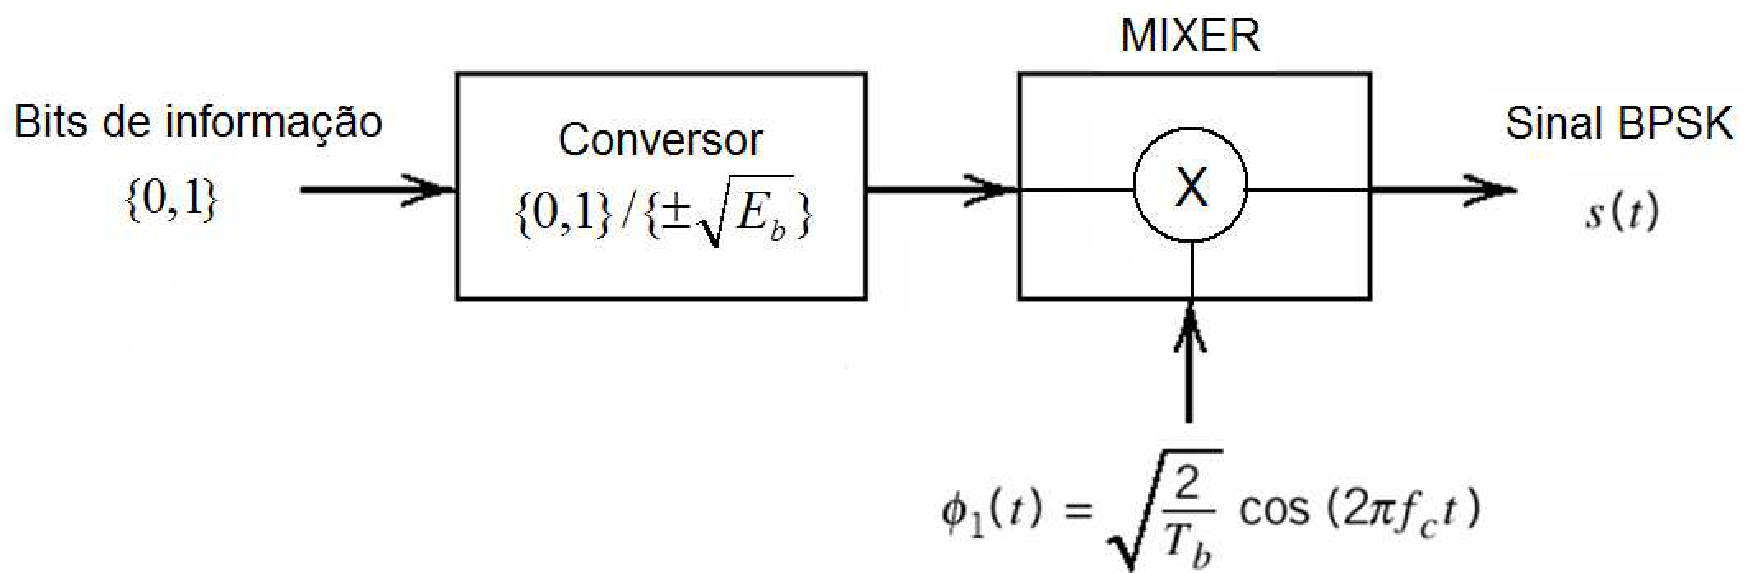

**Observações sobre os blocos:**

a) O bloco **Conversor** é um codificador de linha **NRZ polar** com
   amplitudes $\pm\sqrt{E_b}$: bit 1 → $+\sqrt{E_b}$; bit 0 → $-\sqrt{E_b}$.

b) O bloco **Mixer** é apenas a multiplicação da saída do conversor pela
   função-base (portadora utilizada):
$$\phi_1(t) = \sqrt{\frac{2}{T_b}}\cos(2\pi f_c t)$$

   de modo que o sinal transmitido é
$$s(t) = \pm\sqrt{E_b}\,\phi_1(t) = \pm\sqrt{\frac{2E_b}{T_b}}\cos(2\pi f_c t),
  \qquad 0 \le t < T_b$$

   Note que $-\cos(\cdot) = \cos(\cdot + \pi)$: os dois símbolos diferem
   apenas por uma inversão de fase de 180°.

**O que fazer:**
1. Complete a função `modula_bpsk` abaixo (os `TODO`s).
2. Gere o sinal $s(t)$ para os 10 bits da Seção 1.
3. Plote a saída do conversor NRZ polar e $s(t)$ no domínio do tempo
   (sugestão: dois subplots alinhados no mesmo eixo de tempo, para que as
   inversões de fase fiquem visíveis nas transições de bit).
4. Plote o espectro de amplitude de $s(t)$ (via FFT) no domínio da
   frequência, identificando $f_c$ no gráfico.

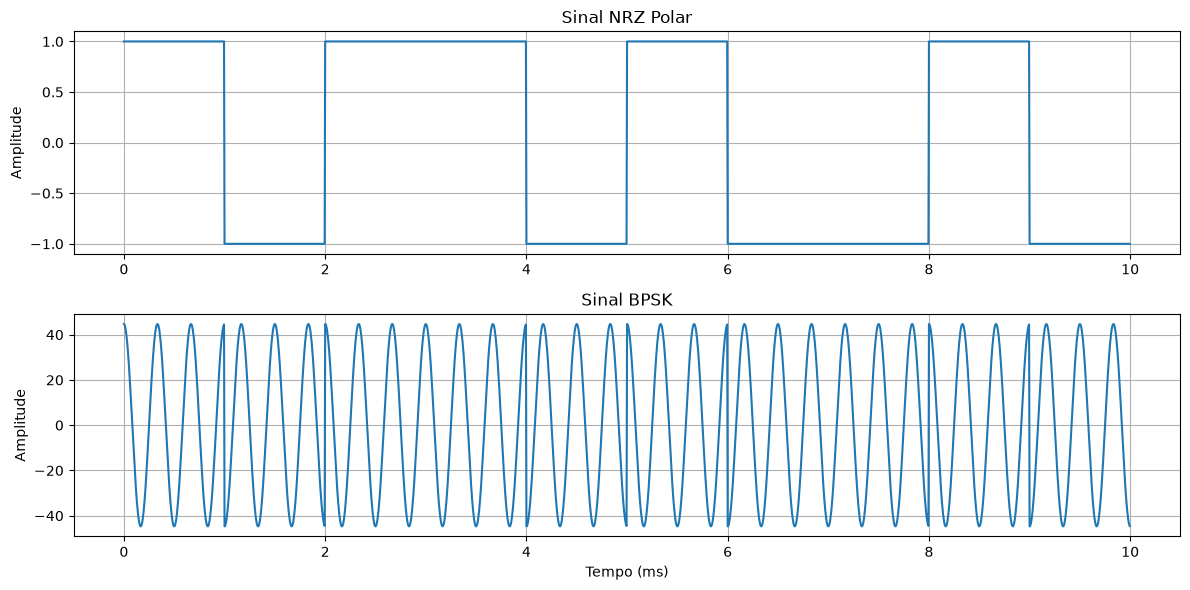

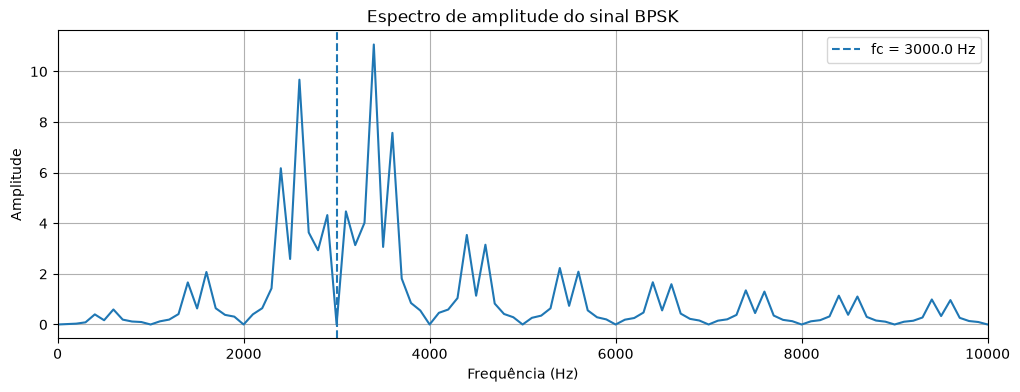

In [103]:
Eb = 1.0
fs = 200_000

def modula_bpsk(bits, fc, Tb, Eb, fs):

    n_amostras_por_bit = int(round(Tb * fs))

    t = np.arange(len(bits) * n_amostras_por_bit) / fs

    # Função-base
    phi1 = np.sqrt(2 / Tb) * np.cos(2 * np.pi * fc * t)

    # Conversor NRZ polar
    nrz_bits = np.where(bits == 1, np.sqrt(Eb), -np.sqrt(Eb))
    nrz = np.repeat(nrz_bits, n_amostras_por_bit)

    # Mixer
    s = nrz * phi1

    return t, nrz, s


t, nrz, s = modula_bpsk(
    params["bits"],
    params["fc"],
    params["Tb"],
    Eb,
    fs
)


# -------------------------
# Domínio do tempo
# -------------------------

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t * 1000, nrz)
plt.ylabel("Amplitude")
plt.title("Sinal NRZ Polar")
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(t * 1000, s)
plt.xlabel("Tempo (ms)")
plt.ylabel("Amplitude")
plt.title("Sinal BPSK")
plt.grid()

plt.tight_layout()
plt.show()


# -------------------------
# Espectro
# -------------------------

N = len(s)

S = np.fft.fft(s)
f = np.fft.fftfreq(N, 1 / fs)

mask = f >= 0

plt.figure(figsize=(12, 4))
plt.plot(f[mask], np.abs(S[mask]) / N)

plt.axvline(
    params["fc"],
    linestyle="--",
    label=f"fc = {params['fc']} Hz"
)

plt.xlabel("Frequência (Hz)")
plt.ylabel("Amplitude")
plt.title("Espectro de amplitude do sinal BPSK")
plt.xlim(0, 10000)
plt.grid()
plt.legend()
plt.show()

---
## 3. Demodulador BPSK (receptor por correlação)

Implemente um código que demodule o sinal BPSK gerado na Seção 2 (ainda
**sem ruído**), segundo o diagrama abaixo.

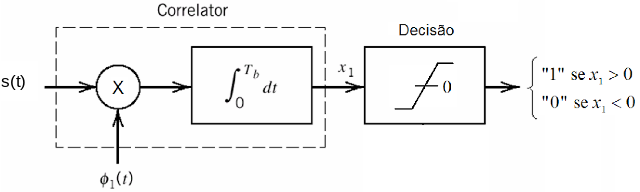

**Observações sobre os blocos:**

a) O bloco **Correlator** multiplica o sinal modulado pela **mesma
   função-base** $\phi_1(t)$ usada na modulação e faz a integral do
   resultado a cada intervalo de bit $T_b$:
$$x_1 = \int_{(i-1)T_b}^{iT_b} s(t)\,\phi_1(t)\,dt$$

b) O bloco **Decisão** verifica a polaridade de $x_1$: se $x_1 > 0$, bit
   **1** identificado; caso contrário ($x_1 < 0$), bit **0** reconhecido.

**O que fazer:**
1. Complete `demodula_bpsk`. Use o **mesmo vetor de tempo** `t` da
   modulação para gerar $\phi_1(t)$ no receptor (isto é, receptor
   perfeitamente sincronizado em fase com o transmissor).
2. Aplique-a ao sinal da Seção 2.
3. Imprima os valores de $x_1$ para cada bit e verifique se estão próximos
   do valor teórico esperado ($\pm\sqrt{E_b}$).
4. Mostre a sequência de bits original e a sequência demodulada (sinal
   após o bloco de Decisão) — em gráfico (ex.: `plt.step`, um subplot para
   cada) e em texto — e confirme que são idênticas (canal ainda ideal).

In [104]:
def demodula_bpsk(t, s, fc, Tb, fs):

    """
    Retorna (bits_rx, x1):

      bits_rx : array de bits demodulados (saída do bloco Decisão)

      x1      : array com a saída do Correlator para cada bit
    """

    n_amostras_por_bit = int(round(Tb * fs))
    n_bits = len(s) // n_amostras_por_bit

    # Mesma função-base usada na modulação
    phi1 = np.sqrt(2 / Tb) * np.cos(2 * np.pi * fc * t)

    x1 = np.zeros(n_bits)
    bits_rx = np.zeros(n_bits, dtype=int)

    for i in range(n_bits):

        ini, fim = i * n_amostras_por_bit, (i + 1) * n_amostras_por_bit

        # Correlator
        x1[i] = np.sum(s[ini:fim] * phi1[ini:fim]) / fs

        # Decisão
        bits_rx[i] = 1 if x1[i] > 0 else 0

    return bits_rx, x1

In [105]:
bits_rx, x1 = demodula_bpsk(
    t, s,
    params["fc"],
    params["Tb"],
    fs
)

print("x1 por bit:      ", np.round(x1, 4))

print("Bits originais:  ", params["bits"])

print("Bits demodulados:", bits_rx)

print("Identicos?", np.array_equal(params["bits"], bits_rx))

x1 por bit:       [ 1. -1.  1.  1. -1.  1. -1. -1.  1. -1.]
Bits originais:   [1 0 1 1 0 1 0 0 1 0]
Bits demodulados: [1 0 1 1 0 1 0 0 1 0]
Identicos? True


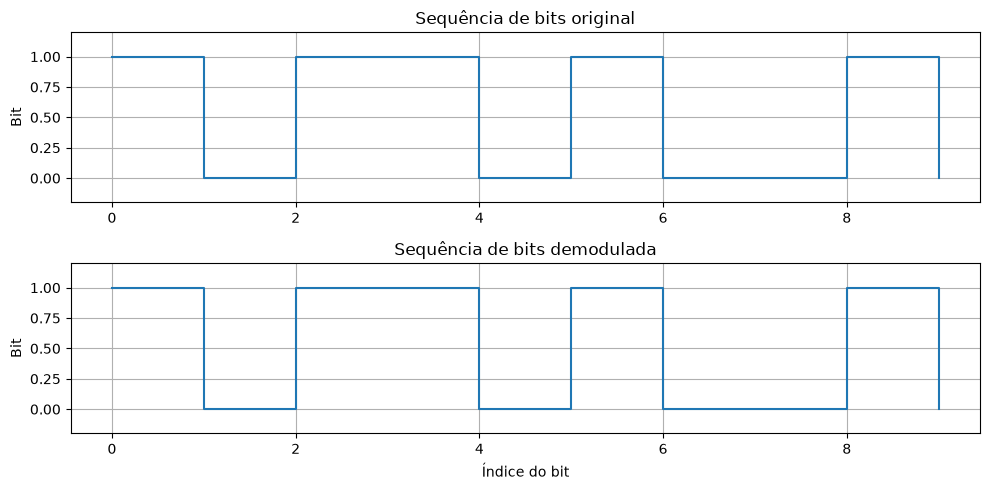

In [106]:
plt.figure(figsize=(10, 5))

plt.subplot(2, 1, 1)
plt.step(
    np.arange(len(params["bits"])),
    params["bits"],
    where="post"
)
plt.ylabel("Bit")
plt.title("Sequência de bits original")
plt.ylim(-0.2, 1.2)
plt.grid()

plt.subplot(2, 1, 2)
plt.step(
    np.arange(len(bits_rx)),
    bits_rx,
    where="post"
)
plt.xlabel("Índice do bit")
plt.ylabel("Bit")
plt.title("Sequência de bits demodulada")
plt.ylim(-0.2, 1.2)
plt.grid()

plt.tight_layout()
plt.show()

---
## 4. Canal com ruído (AWGN) e curva de BER

Um receptor que só funciona sem ruído não diz muito sobre um sistema de
comunicação real. Nesta seção você vai:

1. Usar o canal AWGN fornecido, que adiciona ruído gaussiano branco a
   $s(t)$ para um dado $E_b/N_0$.
2. Gerar uma sequência **longa** de bits (não apenas 10 — use pelo menos
   $10^4$ bits) com os mesmos `fc` e `Tb` da Seção 1.
3. Para uma faixa de $E_b/N_0$ (por exemplo, de 0 a 10 dB, em passos de 1
   ou 2 dB), simular transmissão + canal + recepção e calcular a BER
   (taxa de erro de bit) simulada.
4. Plotar a BER simulada (eixo y em escala log) versus $E_b/N_0$ (dB),
   **sobrepondo a curva teórica** da BPSK coerente:
$$P_e = Q\!\left(\sqrt{\frac{2E_b}{N_0}}\right)
      = \frac{1}{2}\,\mathrm{erfc}\!\left(\sqrt{\frac{E_b}{N_0}}\right), \qquad
  Q(x) = \frac{1}{2}\,\mathrm{erfc}\!\left(\frac{x}{\sqrt{2}}\right)$$
5. (Opcional, recomendado) Para um valor de $E_b/N_0$ baixo (ex.: 0 dB),
   plote o histograma dos valores de $x_1$ recebidos — o que você observa
   em torno de $\pm\sqrt{E_b}$?

**Antes de rodar a simulação:** calcule à mão (ou em uma célula separada,
sem usar a LLM para o cálculo em si) o valor teórico de $P_e$ para pelo
menos dois pontos de $E_b/N_0$ da sua faixa, e anote o resultado em uma
célula de markdown — isso será conferido depois.

### Cálculo teórico manual de $P_e$

Para a BPSK coerente, a probabilidade teórica de erro é:

$$
P_e =
\frac{1}{2}\operatorname{erfc}
\left(
\sqrt{\frac{E_b}{N_0}}
\right)
$$

A conversão de dB para escala linear é:

$$
\frac{E_b}{N_0}_{\text{linear}}
=
10^{\frac{(E_b/N_0)_{\text{dB}}}{10}}
$$

| $E_b/N_0$ (dB) | $E_b/N_0$ (linear) | $P_e$ calculado |
|---:|---:|---:|
| 0 dB | 1 | 0.07865 |
| 10 dB | 10 | $3.872\times10^{-6}$ |

Para $E_b/N_0=0$ dB:

$$
P_e =
\frac{1}{2}\operatorname{erfc}(\sqrt{1})
\approx 0.07865
$$

Para $E_b/N_0=10$ dB:

$$
P_e =
\frac{1}{2}\operatorname{erfc}(\sqrt{10})
\approx 3.872\times10^{-6}
$$

In [107]:
def canal_awgn(s, EbN0_dB, Eb, Tb, fs):
    """Adiciona ruido gaussiano branco a s, para a relacao Eb/N0 (em dB) dada."""
    EbN0 = 10 ** (EbN0_dB / 10)
    N0 = Eb / EbN0
    var_ruido = N0 * fs / 2
    ruido = np.random.normal(0, np.sqrt(var_ruido), size=len(s))
    return s + ruido

def calcula_ber(n_bits, EbN0_dB, fc, Tb, Eb, fs, rng):
    bits = rng.integers(0, 2, size=n_bits)
    t, nrz, s = modula_bpsk(bits, fc, Tb, Eb, fs)
    s_ruidoso = canal_awgn(s, EbN0_dB, Eb, Tb, fs)
    bits_rx, x1 = demodula_bpsk(t, s_ruidoso, fc, Tb, fs)
    n_erros = np.sum(bits != bits_rx)
    return n_erros / n_bits

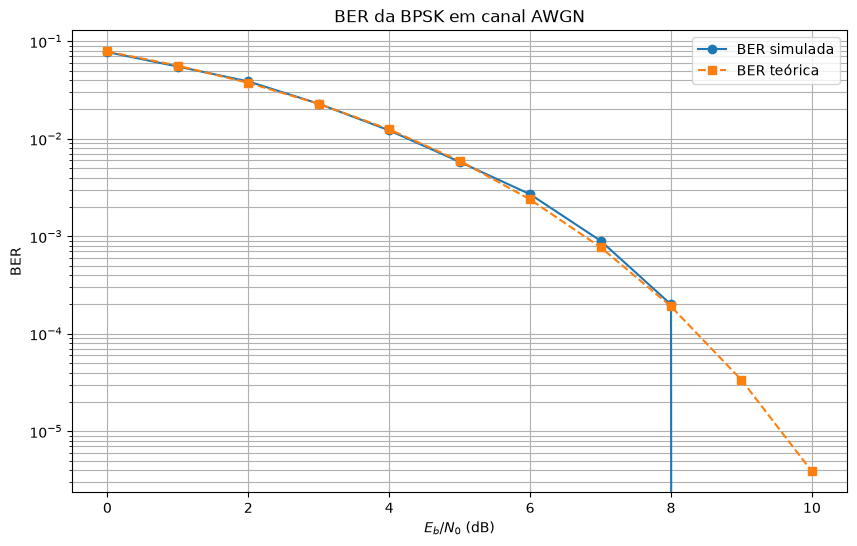

In [108]:
# Número de bits e faixa de Eb/N0
n_bits = 10_000

EbN0_dB_range = np.arange(0, 11, 1)

rng = np.random.default_rng(params["seed"])

# BER simulada
ber_simulada = []

for EbN0_dB in EbN0_dB_range:

    ber = calcula_ber(
        n_bits,
        EbN0_dB,
        params["fc"],
        params["Tb"],
        Eb,
        fs,
        rng
    )

    ber_simulada.append(ber)

# BER teórica
ber_teorica = 0.5 * erfc(
    np.sqrt(10 ** (np.array(EbN0_dB_range) / 10))
)

# Plot
plt.figure(figsize=(10, 6))

plt.semilogy(
    EbN0_dB_range,
    ber_simulada,
    'o-',
    label="BER simulada"
)

plt.semilogy(
    EbN0_dB_range,
    ber_teorica,
    's--',
    label="BER teórica"
)

plt.xlabel(r"$E_b/N_0$ (dB)")
plt.ylabel("BER")
plt.title("BER da BPSK em canal AWGN")
plt.grid(True, which="both")
plt.legend()

plt.show()

---
## 5. Ocupação espectral

Usando o sinal $s(t)$ **sem ruído** da Seção 2 (se quiser uma estimativa
mais suave do espectro, gere uma sequência mais longa de bits aleatórios
com os mesmos `fc` e `Tb`):

1. Estime a largura de banda ocupada pelo sinal BPSK (por exemplo, banda
   que contém 99% da energia do sinal, e/ou a largura entre os primeiros
   nulos do lóbulo principal).
2. Compare o valor obtido com o valor teórico da largura entre nulos do
   lóbulo principal da BPSK, $B = 2/T_b$ (centrada em $f_c$).
3. Relacione esse resultado com as faixas ISM (433 MHz,
   915 MHz, 2,4 GHz, 5,8 GHz): supondo que seu sinal fosse transladado
   para operar dentro de uma dessas faixas, ele caberia dentro dos
   limites de banda tipicamente permitidos para aquela faixa? Justifique.

In [109]:
# ==========================================
# 5. Ocupação espectral
# ==========================================

# Gerar uma sequência longa de bits
rng_espectro = np.random.default_rng(params["seed"])

n_bits_espectro = 10_000

bits_espectro = rng_espectro.integers(
    0, 2,
    size=n_bits_espectro
)

# Gerar o sinal BPSK sem ruído
t_long, nrz_long, s_long = modula_bpsk(
    bits_espectro,
    params["fc"],
    params["Tb"],
    Eb,
    fs
)


# ==========================================
# FFT
# ==========================================

N = len(s_long)

S = np.fft.fft(s_long)
f = np.fft.fftfreq(N, 1 / fs)

# Considerar somente frequências positivas
mask = f >= 0

f_pos = f[mask]
S_pos = S[mask]

# Energia espectral
energia = np.abs(S_pos) ** 2

energia_total = np.sum(energia)


# ==========================================
# Banda que contém 99% da energia
# ==========================================

fc = params["fc"]
Tb = params["Tb"]

# Ordena as frequências pela distância em relação a fc
ordem = np.argsort(np.abs(f_pos - fc))

# Energia acumulada partindo de fc
energia_acumulada = np.cumsum(energia[ordem])

# Primeiro ponto que contém 99% da energia
indice_99 = np.where(
    energia_acumulada >= 0.99 * energia_total
)[0][0]

# Distância desse ponto até fc
distancia_99 = np.abs(
    f_pos[ordem[indice_99]] - fc
)

# Banda total centrada em fc
B_99 = 2 * distancia_99


# ==========================================
# Largura teórica entre os primeiros nulos
# ==========================================

B_teorica = 2 / Tb


# ==========================================
# Resultados
# ==========================================

print(f"fc = {fc:.1f} Hz")
print(f"Tb = {Tb:.6f} s")
print(f"Bits utilizados no espectro = {n_bits_espectro}")

print()
print(f"Banda de 99% da energia:        {B_99:.1f} Hz")
print(f"Banda teórica entre os nulos:   {B_teorica:.1f} Hz")
print(f"Banda teórica:                  {B_teorica/1000:.2f} kHz")
print(f"Banda de 99%:                   {B_99/1000:.2f} kHz")

fc = 3000.0 Hz
Tb = 0.001000 s
Bits utilizados no espectro = 10000

Banda de 99% da energia:        34189.6 Hz
Banda teórica entre os nulos:   2000.0 Hz
Banda teórica:                  2.00 kHz
Banda de 99%:                   34.19 kHz


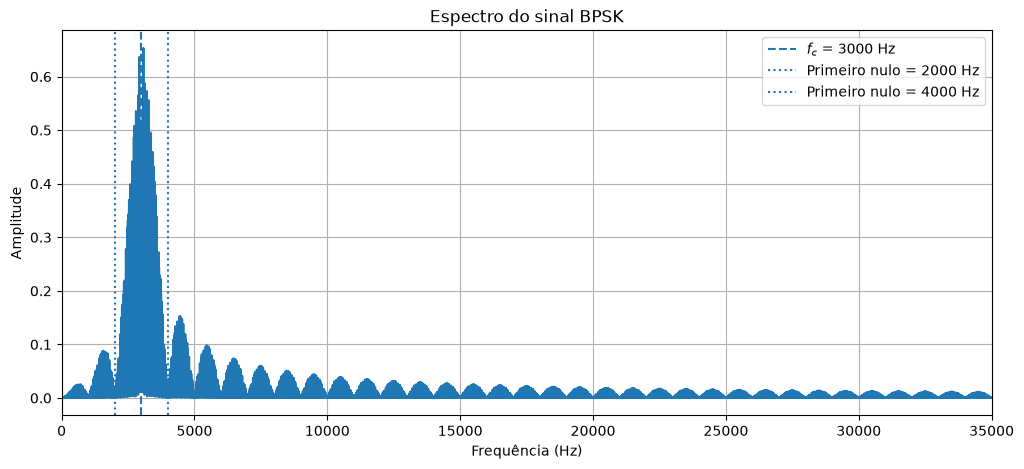

In [110]:
plt.figure(figsize=(12, 5))

plt.plot(
    f_pos,
    np.abs(S_pos) / N
)

plt.axvline(
    fc,
    linestyle="--",
    label=f"$f_c$ = {fc:.0f} Hz"
)

plt.axvline(
    fc - 1/Tb,
    linestyle=":",
    label=f"Primeiro nulo = {fc - 1/Tb:.0f} Hz"
)

plt.axvline(
    fc + 1/Tb,
    linestyle=":",
    label=f"Primeiro nulo = {fc + 1/Tb:.0f} Hz"
)

plt.xlabel("Frequência (Hz)")
plt.ylabel("Amplitude")
plt.title("Espectro do sinal BPSK")
plt.xlim(0, 35000)
plt.grid()
plt.legend()

plt.show()

2.

A largura de banda teórica entre os primeiros nulos do espectro BPSK é dada por:

$$ B = \frac{2}{T_b} $$

Como Tb = 1ms:

$$ B = \frac{2}{0{,}001} = 2000\,\text{Hz} = 2\,\text{kHz} $$

Como a frequência da portadora é fc=3kHz, os primeiros nulos devem ocorrer em:

$$ f_c-\frac{1}{T_b}=3-1=2\,\text{kHz} $$ $$ f_c+\frac{1}{T_b}=3+1=4\,\text{kHz} $$

Portanto, a largura do lóbulo principal observada no espectro é aproximadamente 2kHz, coincidindo com o valor teórico.

A largura de banda de aproximadamente 34kHz obtida pelo critério de 99% de energia é maior porque esse critério também considera a energia presente nos diversos lóbulos laterais do espectro. Assim, os valores de 2 kHz e 34,2 kHz representam critérios diferentes de largura de banda.

3.

Mesmo considerando a largura de aproximadamente 34kHz obtida pelo critério de 99% de energia, ela é muito menor que a largura das faixas ISM na ordem de centenas de MHz. Portanto, em termos de largura de banda, o sinal BPSK poderia ser acomodado nessas faixas após a translação da portadora para a frequência desejada.

Entretanto, isso não significa que qualquer transmissão BPSK possa ser realizada livremente nessas bandas. Na prática, devem ser considerados também os limites de potência, emissões fora da faixa, canalização e demais regulamentações aplicáveis à faixa escolhida.

---
## 6. Perguntas "e se...?"

Responda em células de markdown, com justificativa técnica (não apenas a
conclusão). Estas perguntas **não têm uma resposta que se obtenha apenas
rodando o código anterior** — exigem que você raciocine sobre o que
aconteceria.

1. **Ciclos por bit:** verifique se o seu `ciclos_por_bit` ($f_c T_b$,
   Seção 1) é inteiro. Se não for, cada intervalo de bit **não** contém um
   número inteiro de ciclos da portadora. Isso afetou o valor de $x_1$
   obtido na Seção 3 (compare com $\pm\sqrt{E_b}$) ou a BER da Seção 4?
   Por quê (ou por que não)? Relacione com a energia de $\phi_1(t)$ em um
   intervalo $T_b$.

2. **Referência de fase "reiniciada":** suponha que o receptor gerasse
   $\phi_1(t)$ com um tempo local que recomeça em zero a cada bit (isto é,
   usando $t_{bit} \in [0, T_b)$ em vez do tempo absoluto $t$). Para o
   **seu** valor de $f_c T_b$, isso funcionaria? Explique o que
   aconteceria com a fase da referência de bit para bit.

3. **Erro de fase no receptor:** se a portadora do receptor tivesse um erro
   de fase constante $\theta$ em relação à do transmissor, ou seja,
   $\hat\phi_1(t) = \sqrt{2/T_b}\cos(2\pi f_c t + \theta)$, qual seria a
   expressão aproximada de $x_1$? O que acontece com a BER quando
   $\theta = 30^\circ$, $\theta = 90^\circ$ e $\theta = 180^\circ$? Por que
   o caso de 180° é particularmente traiçoeiro em BPSK? (Não é necessário
   simular — descreva o raciocínio; se quiser, confirme depois simulando.)

4. **E se $T_b$ dobrasse** (bits duas vezes mais longos), mantendo $f_c$ e
   $E_b/N_0$ fixos? O que aconteceria com a BER? E com a banda ocupada
   (Seção 5)? E com a taxa de transmissão? Justifique com base na teoria,
   não apenas rodando a simulação.

5. **Modo de falha mais provável:** dado tudo o que você observou neste
   laboratório, qual você diria que é o modo de falha mais provável de um
   sistema BPSK coerente como este em uma aplicação real (por exemplo, um
   enlace de sensores IoT em 915 MHz)? Justifique.

### 1. Ciclos por bit

Para os parâmetros utilizados no laboratório, temos:

$$
f_c T_b = 3000 \cdot 0{,}001 = 3
$$

Portanto, o número de ciclos por bit é inteiro. Cada intervalo de bit contém exatamente 3 ciclos completos da portadora.

A função de base utilizada pelo receptor é:

$$
\phi_1(t) = \sqrt{\frac{2}{T_b}}\cos(2\pi f_c t)
$$

A energia dessa função em um intervalo de bit é:

$$
E_{\phi} =
\int_0^{T_b} \phi_1^2(t)\,dt
$$

Substituindo a expressão de $\phi_1(t)$:

$$
E_{\phi} =
\frac{2}{T_b}
\int_0^{T_b}
\cos^2(2\pi f_c t)\,dt
$$

Como o intervalo contém exatamente 3 ciclos completos, a média de $\cos^2(\cdot)$ nesse intervalo é $1/2$. Assim:

$$
E_{\phi} =
\frac{2}{T_b}\frac{T_b}{2}
= 1
$$

Portanto, a função de base está normalizada. No caso sem ruído, o correlator produz:

$$
x_1 = \pm\sqrt{E_b}
$$

Como neste laboratório $E_b = 1$, os valores esperados são:

$$
x_1 = \pm 1
$$

Isso foi confirmado na Seção 3, onde os valores obtidos foram $+1$ para os bits 1 e $-1$ para os bits 0.

Portanto, o fato de $f_cT_b$ ser inteiro não introduziu erro na demodulação e não afetou negativamente a BER. Os erros observados na Seção 4 são decorrentes do ruído AWGN.

### 2. Referência de fase "reiniciada"

Neste laboratório, temos:

$$
f_cT_b = 3
$$

Portanto, durante cada intervalo de bit a portadora completa exatamente 3 ciclos.

A variação de fase durante um bit é:

$$
\Delta\phi = 2\pi f_cT_b
$$

Substituindo os valores:

$$
\Delta\phi = 2\pi\cdot3 = 6\pi
$$

Como a fase é periódica em $2\pi$:

$$
6\pi \equiv 0 \pmod{2\pi}
$$

Assim, a portadora termina cada intervalo de bit na mesma fase em que começou. Consequentemente, se o receptor reiniciasse o seu tempo local em zero a cada bit, a referência gerada seria novamente:

$$
\hat{\phi}_1(t_{bit}) =
\sqrt{\frac{2}{T_b}}
\cos(2\pi f_ct_{bit})
$$

e estaria alinhada em fase com a portadora do transmissor no início de cada bit.

Portanto, para o valor de $f_cT_b=3$ utilizado neste laboratório, essa estratégia funcionaria e não introduziria erro adicional na demodulação.

Se $f_cT_b$ não fosse inteiro, a fase da portadora ao final de cada bit seria diferente da fase inicial. Nesse caso, reiniciar a referência em zero a cada bit faria com que a referência do receptor perdesse o alinhamento de fase com a portadora do transmissor, podendo causar erro na saída do correlator e aumentar a BER.

### 3. Erro de fase no receptor

Supondo um erro de fase constante $\theta$ entre o transmissor e o receptor, a referência utilizada pelo receptor é:

$$
\hat{\phi}_1(t) =
\sqrt{\frac{2}{T_b}}
\cos(2\pi f_ct+\theta)
$$

O correlator calcula o produto entre o sinal recebido e essa referência. Utilizando a identidade trigonométrica

$$
\cos(A)\cos(A+\theta)
=
\frac{1}{2}
\left[
\cos(\theta)+\cos(2A+\theta)
\right]
$$

e considerando que o segundo termo possui média zero durante o intervalo de integração, obtemos aproximadamente:

$$
x_1 \approx \pm\sqrt{E_b}\cos(\theta)
$$

Assim, o erro de fase reduz a amplitude da saída do correlator por um fator $\cos(\theta)$.

Para $\theta=30^\circ$:

$$
\cos(30^\circ)\approx0{,}866
$$

e, portanto,

$$
x_1\approx\pm0{,}866\sqrt{E_b}
$$

Os símbolos continuam com sinais opostos, então a decisão ainda funciona sem ruído. Entretanto, como a distância entre os símbolos é menor, a BER aumenta na presença de ruído.

Para $\theta=90^\circ$:

$$
\cos(90^\circ)=0
$$

Logo,

$$
x_1\approx0
$$

para os dois símbolos. O receptor não consegue mais distinguir os bits, resultando em uma decisão essencialmente aleatória e em uma BER próxima de $0{,}5$.

Para $\theta=180^\circ$:

$$
\cos(180^\circ)=-1
$$

e:

$$
x_1\approx\mp\sqrt{E_b}
$$

Nesse caso, os símbolos são completamente invertidos. O receptor interpreta os bits 1 como 0 e os bits 0 como 1. Portanto, no caso ideal sem ruído, a BER pode chegar a:

$$
\mathrm{BER}\approx1
$$

O caso de $180^\circ$ é particularmente traiçoeiro porque o receptor ainda obtém valores com a magnitude correta, mas com o sinal invertido. Assim, em vez de perceber uma ausência de sinal, ele toma decisões consistentes, porém todas incorretas.

### 4. E se $T_b$ dobrasse?

Se o tempo de duração de cada bit dobrasse, teríamos:

$$
T_b' = 2T_b
$$

**BER:**

A BER teórica da BPSK em canal AWGN é dada por:

$$
P_b =
\frac{1}{2}
\operatorname{erfc}
\left(
\sqrt{\frac{E_b}{N_0}}
\right)
$$

Como a questão estabelece que $E_b/N_0$ permanece constante, a BER também permanece constante. Portanto:

$$
\boxed{\text{BER não muda}}
$$

Isso ocorre porque a BER depende da relação entre a energia por bit e a densidade espectral de potência do ruído, e não diretamente da duração do bit.

**Largura de banda:**

Para a largura entre os primeiros nulos do espectro BPSK:

$$
B=\frac{2}{T_b}
$$

Como $T_b$ dobra:

$$
B'=\frac{2}{2T_b}
=\frac{B}{2}
$$

No laboratório, a largura teórica original era:

$$
B=\frac{2}{0{,}001}=2000\,\text{Hz}=2\,\text{kHz}
$$

Com $T_b'=2\,\text{ms}$:

$$
B'=\frac{2}{0{,}002}
=1000\,\text{Hz}
=1\,\text{kHz}
$$

Portanto, a largura de banda passa a ser metade da original.

**Taxa de transmissão:**

A taxa de bits é:

$$
R_b=\frac{1}{T_b}
$$

Como $T_b$ dobra:

$$
R_b'=\frac{1}{2T_b}
=\frac{R_b}{2}
$$

A taxa original era:

$$
R_b=\frac{1}{0{,}001}=1000\,\text{bit/s}
$$

e passaria para:

$$
R_b'=\frac{1}{0{,}002}=500\,\text{bit/s}
$$

Portanto, ao dobrar $T_b$, a BER permanece a mesma quando $E_b/N_0$ é mantido fixo, enquanto a largura de banda e a taxa de transmissão são reduzidas pela metade.

Em resumo:

$$
\boxed{\text{BER: igual}}
$$

$$
\boxed{\text{Largura de banda: metade}}
$$

$$
\boxed{\text{Taxa de transmissão: metade}}
$$

### 5. Modo de falha mais provável

Para um sistema BPSK coerente em uma aplicação real, como um enlace de sensores IoT em 915 MHz, um dos modos de falha mais críticos seria a **perda ou erro de sincronização da fase da portadora** no receptor.

Isso ocorre porque o demodulador coerente depende de uma referência de portadora sincronizada com a utilizada pelo transmissor. Como visto anteriormente, com um erro de fase $\theta$, a saída do correlator é aproximadamente:

$$
x_1 \approx \pm\sqrt{E_b}\cos(\theta)
$$

Assim, um pequeno erro de fase reduz a amplitude dos símbolos e diminui a margem contra o ruído. Por exemplo, para $\theta=30^\circ$:

$$
\cos(30^\circ)\approx0{,}866
$$

e a saída do correlator passa a ter apenas aproximadamente $86{,}6\%$ da amplitude ideal.

O problema se torna ainda mais grave para erros maiores. Para $\theta=90^\circ$:

$$
\cos(90^\circ)=0
$$

e o receptor deixa de conseguir distinguir os dois símbolos. Já para $\theta=180^\circ$:

$$
\cos(180^\circ)=-1
$$

e os símbolos são invertidos, fazendo com que os bits 0 sejam interpretados como 1 e vice-versa.

Em uma aplicação real, outros fatores também podem causar falhas, como ruído, interferência, desvanecimento do canal e erros de sincronização temporal. Entretanto, em um sistema BPSK **coerente**, a sincronização de fase é especialmente crítica porque a demodulação depende diretamente da referência de portadora.

Portanto, o modo de falha escolhido é a **perda ou erro significativo de sincronização da fase da portadora**, pois isso pode degradar progressivamente a BER ou, em casos extremos, fazer com que o receptor perca completamente a capacidade de distinguir os bits.

---
## 7. Log de uso de IA

Preencha a tabela abaixo com cada interação relevante que você teve com uma
LLM (ChatGPT, Claude, Copilot, etc.) durante este laboratório. Isso é
tratado como **citação de fonte**, não como delação — o objetivo é
documentar seu processo, não penalizar o uso da ferramenta.

| # | Seção do lab | Prompt (resumo) | O que a IA sugeriu | O que você validou/mudou e por quê |
|---|---|---|---|---|
| 1 | 2 | Complete os TODOs e plote a fft de s(t) | Código | Eixo da freqência |
| 2 | 3 | Complete a função | Código | - |
| 3 | 3 | Aplicar o sinal gerado anteriormente e comparar com o resultado teórico | Código | - |
| 4 | 4 | Reescreva o seguinte em markdown para o ipynb (equações) | Código | - |
| 5 | 4 | Com uma sequência longa de bits simular para uma faixa de Eb/No e plotar o resultado simulado x teórico. | Código | (Aqui tive que ficar falando com a LLM para arrumar o gráfico) |
| 6 | 5 | (Tentei um monte de coisa, incluindo mandar o enuncunciado). | Código | (Mudei várias vezes pois não fiquei satisfeito com os resultados. [Ainda não estou]) |
| 7 | 5 | (Usei para reescrever minhas respostas para markdown). | Código | - |
| 8 | 6 | (Para todas as questões, eu dava a minha resposta, e se estava certa a LLM me devolvia o markdown. Se não, me corrigia.). | Código | - |



Adicione quantas linhas forem necessárias. Se você não usou IA em alguma
seção, não é preciso preencher uma linha para ela.

---
## 8. Entregáveis

- Este notebook preenchido (`.ipynb`), com todas as células executadas e
  os gráficos visíveis (não apenas o código): $s(t)$ no tempo e na
  frequência (Seção 2) e sequência original × demodulada (Seção 3).
- A célula de cálculo teórico manual da Seção 4 (os dois pontos de $P_e$
  calculados antes da simulação).
- As respostas da Seção 6 (perguntas "e se...?").
- O log de uso de IA preenchido (Seção 7).